# Assignment 2. Option 2

## Dataset Exploration

In [134]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [135]:
!bash ./src/download_voxconverse.sh

Annotations already present, skipping clone.
Audio already present, skipping download.


## Pyannote-Based System

## Custom Implementation (PyTorch / Torchaudio / PyTorch-Lightning)

In [143]:
from pathlib import Path
from src.dataset import VoxConverseDataset, AudioSampler, make_collate_fn
from torch.utils.data import DataLoader
import soundfile as sf

DATA_DIR = Path("data")
AUDIO_DIR = DATA_DIR / "audio"
ANNOTATIONS_DIR = DATA_DIR / "annotations"
IMG_DIR = Path("img")
MODELS_DIR = Path("models")
DIR_DEV = "dev"
DIR_TEST = "test"
SAMPLE_RATE = 16_000
HOP = 10

In [137]:
dataset_dev = VoxConverseDataset(
  annotations_dir=ANNOTATIONS_DIR / DIR_DEV,
  audio_dir=AUDIO_DIR / DIR_DEV,
  sample_rate=SAMPLE_RATE,
)

dataset_test = VoxConverseDataset(
  annotations_dir=ANNOTATIONS_DIR / DIR_TEST,
  audio_dir=AUDIO_DIR / DIR_TEST,
  sample_rate=SAMPLE_RATE,
)

dev_lengths  = [sf.info(p).frames for p in dataset_dev.audio_files]
test_lengths = [sf.info(p).frames for p in dataset_test.audio_files]

dataloader_dev = DataLoader(
  dataset_dev,
  batch_sampler=AudioSampler(dev_lengths, batch_size=8, shuffle=True),
  collate_fn=make_collate_fn(HOP, SAMPLE_RATE),
)

dataloader_test = DataLoader(
  dataset_test,
  batch_sampler=AudioSampler(dev_lengths, batch_size=8, shuffle=False),
  collate_fn=make_collate_fn(HOP, SAMPLE_RATE),
)

### A Voice Activity Detection (VAD) model using a supervised neural network approach

<div align="center"><img src="img/vad.png" height="800"></div>

torch.Size([8, 53674])
speech fraction: 0.8574914932250977


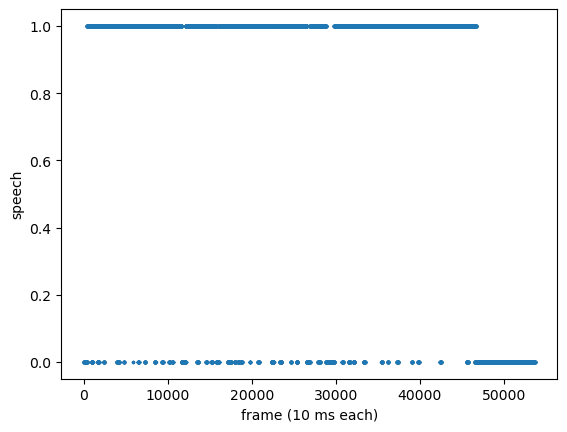

In [138]:
import torch
from torch import nn
import matplotlib.pyplot as plt

(waveform, labels, mask) = next(iter(dataloader_dev))

print(labels.shape)
print("speech fraction:", labels.float().mean().item())
y = labels[0].numpy()
x = range(len(y))

plt.scatter(x, y, s=2)
plt.xlabel("frame (10 ms each)")
plt.ylabel("speech")
plt.show()

In [139]:
import torchaudio.transforms as T
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import warnings

warnings.filterwarnings("ignore", message="An output with one or more elements was resized")

class MelSpectrogramExtractor(nn.Module):
  def __init__(
      self,
      mel_bands: int = 32,
      sample_rate: int = 16000,
      hop_ms: float = 10.0,
      win_ms: float = 25.0,
      n_fft: int = 512,
      eps: float = 1e-6,
  ):
    super().__init__()
    self.mel_bands = mel_bands
    self.eps = eps
    self.hop_ms = hop_ms
    self.melspec = nn.Sequential(
      T.MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=n_fft,
        win_length=int(sample_rate * win_ms / 1000),
        hop_length=int(sample_rate * hop_ms / 1000),
        n_mels=mel_bands,
        normalized=True,
      )
    )

  def forward(self, X):
    mel = self.melspec(X)
    mel = torch.log(mel + self.eps)
    mel = mel.transpose(1, 2)
    return mel

class VoiceActivityDetector(nn.Module):
  def __init__(
    self,
    device: str,
    spectrogram_layer: MelSpectrogramExtractor,
    subsample_size: int = 320,
  ):
    super().__init__()
    self.device = device
    self.spectrogram = spectrogram_layer
    self.subsample_size = subsample_size

    self.cnn = nn.Sequential(
      nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(2),
      nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(2),
      nn.Flatten(),
      nn.Linear(2048, 64),
    )

    self.lstm = nn.LSTM(
      input_size=64,
      hidden_size=128,
      num_layers=2,
      dropout=0.5,
      bidirectional=True,
      batch_first=True,
    )

    self.head = nn.Linear(2 * 128, 1)

  def _chunk(self, mel, labels, mask):
    n_frames = min(mel.shape[1], labels.shape[1])
    mel, labels, mask = mel[:, :n_frames], labels[:, :n_frames], mask[:, :n_frames]

    chunk_size = int(self.subsample_size / self.spectrogram.hop_ms)
    padding = (chunk_size - n_frames % chunk_size) % chunk_size

    if padding:
      mel = F.pad(mel, (0, 0, 0, padding))
      labels = F.pad(labels, (0, padding))
      mask = F.pad(mask, (0, padding), value=False)

    n_chunks = mel.shape[1] // chunk_size
    mel = mel.reshape(mel.shape[0], n_chunks, chunk_size, mel.shape[2])

    labels = labels.reshape(labels.shape[0], n_chunks, chunk_size)
    labels = labels.sum(-1)
    labels = labels > chunk_size // 2

    mask = mask.reshape(mask.shape[0], n_chunks, chunk_size)
    mask = mask.any(-1)

    return mel, labels, mask

  def forward(self, X):
    (waveform, labels, mask) = X

    mel = self.spectrogram(waveform)

    (mel, labels, mask) = self._chunk(mel, labels, mask)

    B, n_chunks, H, W = mel.shape

    Y = mel.reshape(B * n_chunks, 1, H, W)
    Y = self.cnn(Y)
    Y = Y.reshape(B, n_chunks, -1)

    lengths = mask.sum(dim=1).cpu()
    packed = pack_padded_sequence(Y, lengths, batch_first=True, enforce_sorted=False)
    Y, _ = self.lstm(packed)
    Y, _ = pad_packed_sequence(Y, batch_first=True, total_length=n_chunks)
    Y = self.head(Y).squeeze(-1)

    return Y, labels, mask

Device: mps
===== EPOCH 1/7 - train =====
  batch   1 | loss 0.1287 | acc 0.165 | P 0.852 | R 0.053 | F1 0.100 | spec 0.937
  batch  10 | loss 0.0888 | acc 0.061 | P 0.000 | R 0.000 | F1 0.000 | spec 1.000
  batch  20 | loss 0.0755 | acc 0.953 | P 0.953 | R 1.000 | F1 0.976 | spec 0.000
train | acc 0.430 | P 0.939 | R 0.414 | F1 0.575 | spec 0.637
===== EPOCH 1/7 - test =====
  batch   1 | loss 0.1018 | acc 0.190 | P 0.867 | R 0.134 | F1 0.233 | spec 0.781
  batch  10 | loss 0.1250 | acc 0.453 | P 0.887 | R 0.431 | F1 0.581 | spec 0.605
  batch  20 | loss 0.1345 | acc 0.462 | P 0.895 | R 0.422 | F1 0.574 | spec 0.703
test  | acc 0.364 | P 0.933 | R 0.313 | F1 0.469 | spec 0.806
===== EPOCH 2/7 - train =====
  batch   1 | loss 0.0769 | acc 0.222 | P 0.982 | R 0.187 | F1 0.314 | spec 0.930
  batch  10 | loss 0.0606 | acc 0.567 | P 0.998 | R 0.552 | F1 0.711 | spec 0.971
  batch  20 | loss 0.0669 | acc 0.880 | P 0.977 | R 0.892 | F1 0.932 | spec 0.726
train | acc 0.643 | P 0.981 | R 0.629

/var/folders/m7/qn99csmd48s9232z_r7d50nw0000gn/T/ipykernel_27547/3862316410.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


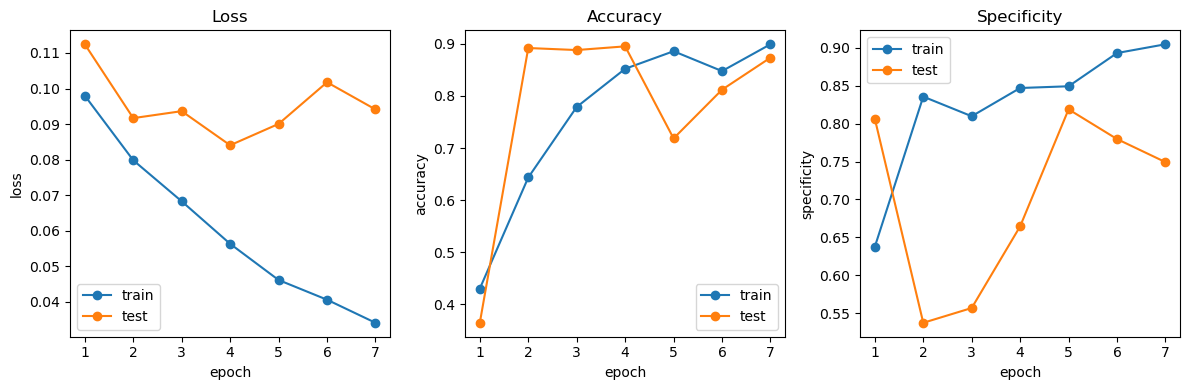

In [142]:
from torchmetrics import MetricCollection
from torchmetrics.classification import (
    BinaryAccuracy, BinaryPrecision, BinaryRecall, BinaryF1Score, BinarySpecificity
)

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
epochs = 7
lr = 1e-3

print(f"Device: {device}")

vad = VoiceActivityDetector(
  device=device,
  spectrogram_layer=MelSpectrogramExtractor(
    sample_rate=SAMPLE_RATE,
    hop_ms=HOP,
  )
)

def fmt_metrics(metrics, order=("acc", "P", "R", "F1", "spec")):
    return " | ".join(f"{k} {metrics[k].item():.3f}" for k in order)

def evaluate_vad(model, x, loss, metrics, opt=None, i=0):
  x = tuple(t.to(device) for t in x)

  pred, labels, mask = model(x)
  pred, labels = pred[mask], labels[mask]

  lvalue = loss(pred, labels.float())

  if opt:
    lvalue.backward()
    opt.step()
    opt.zero_grad()

  stats = metrics(torch.sigmoid(pred), labels.int())
  if i % 10 == 0 or i == 1:
    print(f"  batch {i:3d} | loss {lvalue.item():.4f} | " + fmt_metrics(stats))

  return lvalue.item()

def train():
  vad.to(device)

  frac = 0.936
  pos_weight = torch.tensor([(1 - frac) / frac], device=device)
  loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

  opt = torch.optim.Adam(vad.parameters(), lr=lr)

  train_metrics = MetricCollection({
    "acc": BinaryAccuracy(),
    "P":   BinaryPrecision(),
    "R":   BinaryRecall(),
    "F1":  BinaryF1Score(),
    "spec": BinarySpecificity(),
  }).to(device)

  test_metrics = train_metrics.clone().to(device)

  history = {
    "train_loss": [],
    "test_loss": [],
    "train_acc": [],
    "test_acc": [],
    "train_spec": [],
    "test_spec": [],
  }

  for epoch in range(epochs):
    print(f"===== EPOCH {epoch + 1}/{epochs} - train =====")
    vad.train()
    epoch_loss = 0.0
    for i, x in enumerate(dataloader_dev):
      epoch_loss += evaluate_vad(vad, x, loss, train_metrics, opt, i + 1)

    train_stats = train_metrics.compute()
    history["train_loss"].append(epoch_loss / len(dataloader_dev))
    history["train_acc"].append(train_stats["acc"].item())
    history["train_spec"].append(train_stats["spec"].item())
    print(f"train | {fmt_metrics(train_stats)}")
    train_metrics.reset()

    print(f"===== EPOCH {epoch + 1}/{epochs} - test =====")
    vad.eval()
    epoch_loss = 0.0
    with torch.no_grad():
      for i, x in enumerate(dataloader_test):
        epoch_loss += evaluate_vad(vad, x, loss, test_metrics, opt=None, i=i + 1)

    test_stats = test_metrics.compute()
    history["test_loss"].append(epoch_loss / len(dataloader_test))
    history["test_acc"].append(test_stats["acc"].item())
    history["test_spec"].append(test_stats["spec"].item())
    print(f"test  | {fmt_metrics(test_stats)}")
    test_metrics.reset()

  return history

def plot_history(history):
  xs = range(1, len(history["train_loss"]) + 1)
  fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

  ax1.plot(xs, history["train_loss"], marker="o", label="train")
  ax1.plot(xs, history["test_loss"],  marker="o", label="test")
  ax1.set(title="Loss", xlabel="epoch", ylabel="loss")
  ax1.legend()

  ax2.plot(xs, history["train_acc"], marker="o", label="train")
  ax2.plot(xs, history["test_acc"],  marker="o", label="test")
  ax2.set(title="Accuracy", xlabel="epoch", ylabel="accuracy")
  ax2.legend()

  ax3.plot(xs, history["train_spec"], marker="o", label="train")
  ax3.plot(xs, history["test_spec"],  marker="o", label="test")
  ax3.set(title="Specificity", xlabel="epoch", ylabel="specificity")
  ax3.legend()

  fig.tight_layout()
  return fig

history = train()
fig = plot_history(history)
fig.savefig(IMG_DIR / "vad_metrics.png", dpi=150, bbox_inches="tight")
fig.show()

In [145]:
torch.save(vad.state_dict(), MODELS_DIR / "vad.pt")